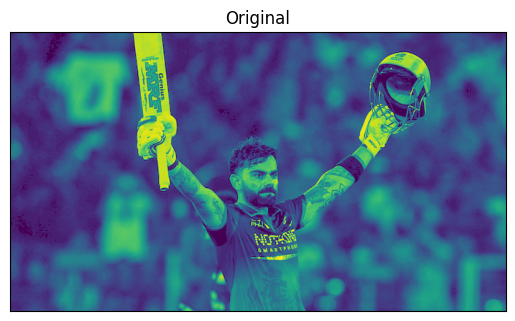

In [ ]:
import cv2
import matplotlib.pyplot as plt 

img = cv2.imread('virat.png', cv2.IMREAD_GRAYSCALE) # At first making gray scale image
plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.show()

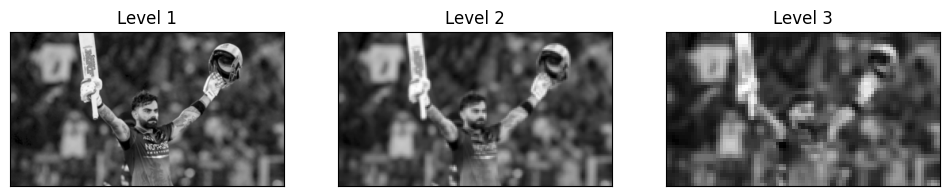

In [7]:
downsampling1 = cv2.pyrDown(img)
downsampling2 = cv2.pyrDown(downsampling1)
downsampling3 = cv2.pyrDown(downsampling2)

plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(downsampling1, cmap='gray')
plt.title('Level 1')
plt.xticks([])
plt.yticks([])

plt.subplot(132)
plt.imshow(downsampling2, cmap='gray')
plt.title('Level 2')
plt.xticks([])
plt.yticks([])

plt.subplot(133)
plt.imshow(downsampling3, cmap='gray')
plt.title('Level 3')
plt.xticks([])
plt.yticks([])

plt.show()


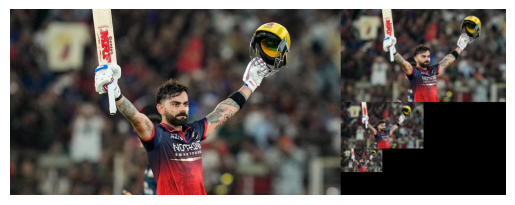

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("virat.png")

g1 = cv2.pyrDown(img)
g2 = cv2.pyrDown(g1)
g3 = cv2.pyrDown(g2)

# Canvas
h, w = img.shape[:2]

canvas = np.zeros((h, w + g1.shape[1], 3), dtype=np.uint8)

canvas[:h, :w] = img
canvas[:g1.shape[0], w:w+g1.shape[1]] = g1
canvas[g1.shape[0]:g1.shape[0]+g2.shape[0], w:w+g2.shape[1]] = g2
canvas[g1.shape[0]+g2.shape[0]:
       g1.shape[0]+g2.shape[0]+g3.shape[0],
       w:w+g3.shape[1]] = g3

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

These image pyramids will be working on image blending application

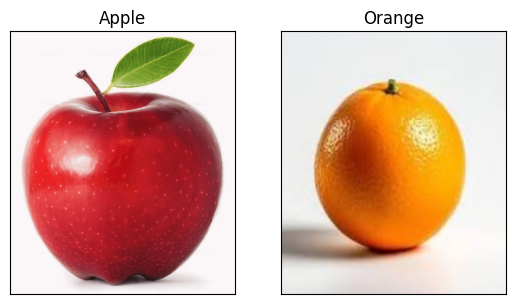

In [25]:
# In image blending, we blend two different kinds of image into 1, 
# Think like belnding of apple and orange

# Algorithm is
# 1. loading two images
# 2. find gaussian pyramids for two images in same order
# 3. from gaussian find their laplacian pyramid
# 4. join each half of laplacian of both images
# 5. joint all and reconstruct image

import cv2
import numpy as np
import matplotlib.pyplot as plt 

# 1. loading images
A = cv2.imread("apple.png", cv2.IMREAD_COLOR_RGB)
orange_pre = cv2.imread('orange.png', cv2.IMREAD_COLOR_RGB)
B = cv2.resize(orange_pre, (515, 600))

plt.subplot(121), plt.imshow(A), plt.title("Apple")
plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(B), plt.title("Orange")
plt.xticks([]), plt.yticks([])

plt.show()


In [26]:
# 2. Gussian pyramid for image A
G = A.copy()
gpA = [G]
for i in range(6):
    G = cv2.pyrDown(G)
    gpA.append(G)

# Gaussian pyramid for B
G = B.copy()
gpB = [G]
for i in range(6):
    G = cv2.pyrDown(G)
    gpB.append(G)


In [29]:
# Step 3: generating laplacian pyramid for both image
lpA = [gpA[5]]
for i in range(5, 0, -1):
    GE = cv2.pyrUp(gpA[i])
    # Sometimes both image size may not be equal
    # resixing the expanded image before subtraction
    GE = cv2.resize(GE, (gpA[i-1].shape[1], gpA[i-1].shape[0]))
    L = cv2.subtract(gpA[i-1],GE)
    lpA.append(L)

lpB = [gpB[5]]
for i in range(5, 0, -1):
    GE = cv2.pyrUp(gpB[i])
    # similarly for this too
    GE = cv2.resize(GE, (gpB[i-1].shape[1], gpB[i-1].shape[0]))
    L = cv2.subtract(gpB[i-1],GE)
    lpB.append(L)


In [31]:
# Step 4: join half of laplacian of both images
# left and right halves of the images are adding
LS = []
for la, lb in zip(lpA, lpB):
    rows, cols, dpt = la.shape
    ls = np.hstack((la[:,:cols//2],lb[:,cols//2:]))
    LS.append(ls)


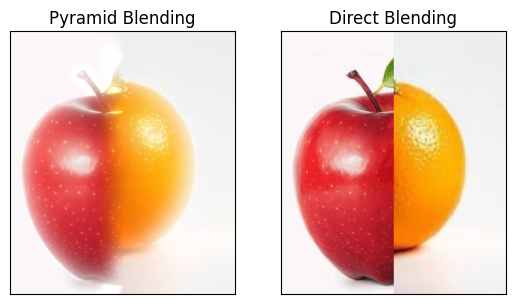

In [35]:
# Step 5: reconstruction of joint
ls_=LS[0]
for i in range(1,6):
    ls_ = cv2.pyrUp(ls_)
    ls_ = cv2.resize(ls_, (LS[i].shape[1], LS[i].shape[0]))
    ls_ = cv2.add(ls_, LS[i])

real = np.hstack((A[:,:cols//2], B[:,cols//2:]))

plt.subplot(121), plt.imshow(ls_), plt.title("Pyramid Blending")
plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(real), plt.title("Direct Blending")
plt.xticks([]), plt.yticks([])

plt.show()